In [ ]:
# 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import numpy as np
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf

In [ ]:
# -------------------------------
# 데이터 증강 함수들
# -------------------------------

In [ ]:
def time_warp(sequence, target_len):
    """시퀀스 길이를 보간(interpolation)으로 변경"""
    current_len = len(sequence)
    if current_len == target_len:
        return sequence
    seq = np.array(sequence)
    x_old = np.linspace(0, 1, current_len)
    x_new = np.linspace(0, 1, target_len)
    warped = np.array([np.interp(x_new, x_old, seq[:,i]) for i in range(seq.shape[1])]).T
    return warped.tolist()

In [ ]:
def add_noise(sequence, noise_level=0.02):
    return (np.array(sequence) + np.random.normal(0, noise_level, size=np.array(sequence).shape)).tolist()

In [ ]:
def horizontal_flip(sequence):
    flipped = np.array(sequence)
    flipped[:, 0::3] = 1.0 - flipped[:, 0::3]  # x 좌표만 반전
    return flipped.tolist()

#X축 반전

In [ ]:
#원본

def augment_sample(sample, num_augmented=29):
    augmented = []
    for _ in range(num_augmented):
        aug = add_noise(sample)
#        if random.random() < 0.5:
#            aug = horizontal_flip(aug)
        aug = time_warp(aug, len(sample))
        augmented.append(aug)
    return augmented

In [ ]:
# -------------------------------
# 데이터 로딩 함수 (증강 포함)
# -------------------------------

In [ ]:
def load_data_from_folders(base_dir, augment=True, num_augmented=29):
    X = []
    y = []
    labels = sorted(os.listdir(base_dir))
    label_map = {label: idx for idx, label in enumerate(labels)}

    for label in labels:
        folder_path = os.path.join(base_dir, label)
        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            with open(file_path) as f:
                frames = json.load(f)
                X.append(frames)
                y.append(label_map[label])

                # 증강 데이터 추가
                if augment:
                    aug_samples = augment_sample(frames, num_augmented=num_augmented)
                    X.extend(aug_samples)
                    y.extend([label_map[label]] * len(aug_samples))

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    return X, y, label_map

In [ ]:
# -------------------------------
# 모델 구성 및 학습
# -------------------------------

In [ ]:
# 데이터 경로 설정
data_dir = "/content/drive/MyDrive/JSON 4Datasets"

# 데이터 로드 (증강 포함)
X, y, label_map = load_data_from_folders(data_dir, augment=True, num_augmented=29)

# 레이블 one-hot 인코딩
y = tf.keras.utils.to_categorical(y, num_classes=len(label_map))

# 학습/검증 분할
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Bidirectional LSTM

from tensorflow.keras.layers import Bidirectional, LSTM

model = tf.keras.Sequential([
    Bidirectional(LSTM(128, return_sequences=True), input_shape=(X.shape[1], X.shape[2])),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    Bidirectional(LSTM(128, return_sequences=True)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    Bidirectional(LSTM(64, return_sequences=True)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    Bidirectional(LSTM(64)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(label_map), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_55                │ (None, 300, 256)       │       261,120 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_56                │ (None, 300, 256)       │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 300, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_56 (Dropout)            │ (None, 300, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_57                │ (None, 300, 128)       │       164,352 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_57 (Dropout)            │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_58                │ (None, 300, 128)       │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 300, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 300, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_59                │ (None, 128)            │        98,816 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_59 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_70 (Dense)                │ (None, 32)             │         1,05

 Total params: 1,037,668 (3.96 MB)

 Trainable params: 1,035,876 (3.95 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [ ]:
class CustomEarlyStopping(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_acc = logs.get('val_accuracy')
        val_loss = logs.get('val_loss')

        # 원하는 조건: val_accuracy >= 0.95 and val_loss <= 0.2
        if val_acc is not None and val_loss is not None:
            if val_acc >= 0.97 and val_loss <= 0.05:
                print(f"\n🚀 조건 만족! (val_accuracy: {val_acc:.4f}, val_loss: {val_loss:.4f}) 학습 조기 종료합니다.")
                self.model.stop_training = True

In [ ]:
# 컴파일
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# 학습
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200, batch_size=32, callbacks=[CustomEarlyStopping()])

Epoch 1/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 136ms/step - accuracy: 0.4086 - loss: 1.2059 - val_accuracy: 0.5466 - val_loss: 1.0373
Epoch 2/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.7519 - loss: 0.5410 - val_accuracy: 0.6152 - val_loss: 0.9074
Epoch 3/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.7874 - loss: 0.4836 - val_accuracy: 0.7451 - val_loss: 0.6210
Epoch 4/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8577 - loss: 0.3013 - val_accuracy: 0.7132 - val_loss: 0.6748
Epoch 5/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8332 - loss: 0.4154 - val_accuracy: 0.7059 - val_loss: 0.8145
Epoch 6/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8638 - loss: 0.3211 - val_accuracy: 0.6397 - val_loss: 2.0806
Epoch 7/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.8453 - loss: 0.3665 - val_accuracy: 0.7206 - val_loss: 1.7371
Epoch 8/200
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.8983 - loss: 0.2518 - val_acc

In [ ]:
# 예측
y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step


In [ ]:
#모델 저장

#model.save('/content/test2.keras')

#from google.colab import files
#files.download('/content/test2.keras')

In [ ]:
# F1 Score 및 기타 평가
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=label_map.keys()))

Classification Report:
                                                 precision    recall  f1-score   support

I don_t think I can hold it in because it hurts       1.00      1.00      1.00       109
                I think I hurt my knee ligament       0.94      1.00      0.97       100
             The glass broke and I hurt my foot       1.00      0.94      0.97        96
             There_s a foreign object in my eye       1.00      1.00      1.00       103

                                       accuracy                           0.99       408
                                      macro avg       0.99      0.98      0.98       408
                                   weighted avg       0.99      0.99      0.99       408



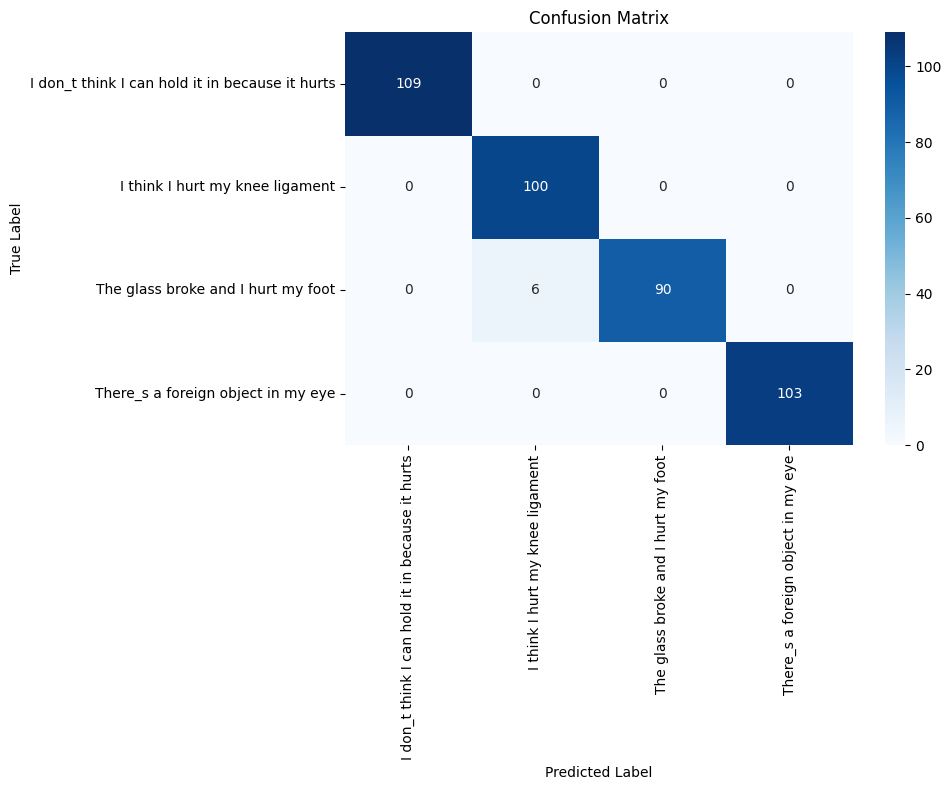

In [ ]:
# 혼동 행렬 시각화
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_map.keys(),
            yticklabels=label_map.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

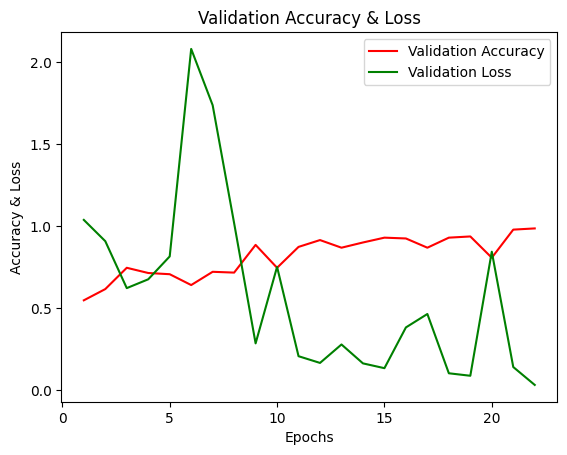

In [ ]:
#정확도 값
import matplotlib.pyplot as plt

history_dict = history.history

val_accuracy = history_dict['val_accuracy']
epochs = range(1, len(val_accuracy)+1)

val_loss = history_dict['val_loss']
epochs = range(1, len(val_loss)+1)

plt.plot(epochs, val_accuracy, 'r', label='Validation Accuracy')
plt.plot(epochs, val_loss, 'g', label='Validation Loss')
plt.title('Validation Accuracy & Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy & Loss')
plt.legend()

plt.show()

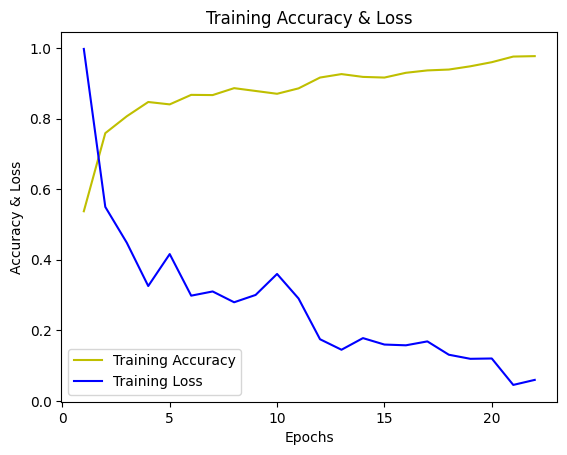

In [ ]:
history_dict = history.history

accuracy = history_dict['accuracy']
epochs = range(1, len(accuracy)+1)

loss = history_dict['loss']
epochs = range(1, len(loss)+1)

plt.plot(epochs, accuracy, 'y', label='Training Accuracy')
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training Accuracy & Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy & Loss')
plt.legend()

plt.show()

In [ ]:
from collections import Counter

# Convert one-hot encoded labels back to class indices
y_classes = np.argmax(y, axis=1)  # Get the class indices from one-hot encoded labels

# 클래스별 데이터 수 세기
class_counts = Counter(y_classes)  # Use y_classes (class indices) instead of y (one-hot)

# 인덱스를 클래스 이름으로 변환
inverse_label_map = {v: k for k, v in label_map.items()}

# 결과 출력
for class_idx, count in sorted(class_counts.items()):
    class_name = inverse_label_map[class_idx]
    print(f"클래스 '{class_name}' (index {class_idx}): {count} 샘플")

클래스 'I don_t think I can hold it in because it hurts' (index 0): 510 샘플
클래스 'I think I hurt my knee ligament' (index 1): 510 샘플
클래스 'The glass broke and I hurt my foot' (index 2): 510 샘플
클래스 'There_s a foreign object in my eye' (index 3): 510 샘플
